# Notebook 06: Winner/Loser Classification

**Goal**: Train a classifier to predict which homeowners benefit (lower
tax bill) under the land-only tax shift, then use SHAP to profile
the characteristics that determine winners and losers.

In [7]:
import pandas as pd
import numpy as np
import json
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve,
)

sns.set_theme(style="whitegrid")

In [8]:
sim = pd.read_parquet("../data/processed/tax_simulation_results.parquet")

with open("../data/processed/feature_config.json") as f:
    config = json.load(f)

CLASS_COL = config["class_col"]
homeowners = sim[sim["is_homeowner"]].copy()
print(f"Homeowners: {len(homeowners):,}")
print(f"Winners (Scenario B): {homeowners['winner_B'].sum():,} "
      f"({100*homeowners['winner_B'].mean():.1f}%)")

Homeowners: 672,719
Winners (Scenario B): 386,576 (57.5%)


## 1. Prepare Classification Features

In [9]:
# Merge property characteristics back from assessment_clean
assessment = pd.read_parquet("../data/processed/assessment_clean.parquet")
char_cols = [c for c in assessment.columns if c.startswith("char_")]
loc_cols = ["loc_latitude", "loc_longitude"]
acs_cols = [c for c in assessment.columns if c.startswith("acs5_")]
prox_cols = [c for c in assessment.columns if c.startswith("prox_")]

merge_cols = ["meta_pin"] + char_cols + loc_cols + acs_cols + prox_cols
merge_cols = [c for c in merge_cols if c in assessment.columns]

# Deduplicate assessment on meta_pin (take first card)
assess_dedup = assessment.drop_duplicates(subset="meta_pin", keep="first")
homeowners = homeowners.merge(
    assess_dedup[merge_cols], on="meta_pin", how="left", suffixes=("", "_dup")
)
# Drop duplicate columns
dup_cols = [c for c in homeowners.columns if c.endswith("_dup")]
homeowners.drop(columns=dup_cols, inplace=True)

print(f"After merge: {homeowners.shape}")

After merge: (672719, 120)


In [10]:
# Define classification features
# These describe the property — NOT the simulation outputs
CLASSIFY_FEATURES = []

# Property characteristics
for col in homeowners.columns:
    if col.startswith(("char_", "feat_")) and col in homeowners.columns:
        CLASSIFY_FEATURES.append(col)

# Key ratios from decomposition
for col in ["site_value_ratio", "pred_total_value", "pred_site_value_adj",
            "pred_improvement_value"]:
    if col in homeowners.columns:
        CLASSIFY_FEATURES.append(col)

# Location (continuous only)
for col in ["loc_latitude", "loc_longitude"]:
    if col in homeowners.columns:
        CLASSIFY_FEATURES.append(col)

# Select ACS features
for col in homeowners.columns:
    if col.startswith("acs5_") and col in homeowners.columns:
        CLASSIFY_FEATURES.append(col)

# Property class as a feature
CLASSIFY_FEATURES.append(CLASS_COL)

# Remove duplicates
CLASSIFY_FEATURES = list(dict.fromkeys(CLASSIFY_FEATURES))
CLASSIFY_FEATURES = [c for c in CLASSIFY_FEATURES if c in homeowners.columns]

# Identify categorical features: explicitly named + any str/object columns
# LightGBM requires all columns to be int, float, bool, or category dtype
CAT_FEATS = [CLASS_COL]
for col in CLASSIFY_FEATURES:
    if col not in CAT_FEATS and homeowners[col].dtype in (object, "string"):
        CAT_FEATS.append(col)

NUM_FEATS = [c for c in CLASSIFY_FEATURES if c not in CAT_FEATS]

# Convert all categorical columns to category dtype
for col in CAT_FEATS:
    homeowners[col] = homeowners[col].astype("category")

print(f"Classification features: {len(CLASSIFY_FEATURES)}")
print(f"  Numeric: {len(NUM_FEATS)}, Categorical: {len(CAT_FEATS)}")
print(f"  Categorical cols: {CAT_FEATS}")

Classification features: 61
  Numeric: 58, Categorical: 3
  Categorical cols: ['meta_class', 'char_class', 'char_recent_renovation']


## 2. Train Winner/Loser Classifier

In [11]:
# Target: winner under Scenario B (land-only, flat rate)
TARGET = "winner_B"

X = homeowners[CLASSIFY_FEATURES].copy()
y = homeowners[TARGET].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

print(f"Train: {len(X_train):,} (winners: {y_train.mean():.1%})")
print(f"Test:  {len(X_test):,} (winners: {y_test.mean():.1%})")

Train: 538,175 (winners: 57.5%)
Test:  134,544 (winners: 57.5%)


In [12]:
lgb_train = lgb.Dataset(X_train, label=y_train,
                         categorical_feature=CAT_FEATS, free_raw_data=False)
lgb_test = lgb.Dataset(X_test, label=y_test,
                        categorical_feature=CAT_FEATS, reference=lgb_train,
                        free_raw_data=False)

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 128,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.7,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 0.5,
    "lambda_l2": 2.0,
    "is_unbalance": True,
    "verbose": -1,
    "seed": 42,
}

clf = lgb.train(
    params, lgb_train, num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    valid_names=["train", "test"],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(100)],
)

Training until validation scores don't improve for 30 rounds
[100]	train's auc: 0.999999	test's auc: 0.999997
[200]	train's auc: 1	test's auc: 0.999998
Early stopping, best iteration is:
[200]	train's auc: 1	test's auc: 0.999998


In [13]:
# Evaluate
y_prob = clf.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

print("=== Classification Report ===\n")
print(classification_report(y_test, y_pred, target_names=["Pay MORE", "Pay LESS"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

=== Classification Report ===

              precision    recall  f1-score   support

    Pay MORE       1.00      1.00      1.00     57229
    Pay LESS       1.00      1.00      1.00     77315

    accuracy                           1.00    134544
   macro avg       1.00      1.00      1.00    134544
weighted avg       1.00      1.00      1.00    134544

ROC AUC: 1.0000


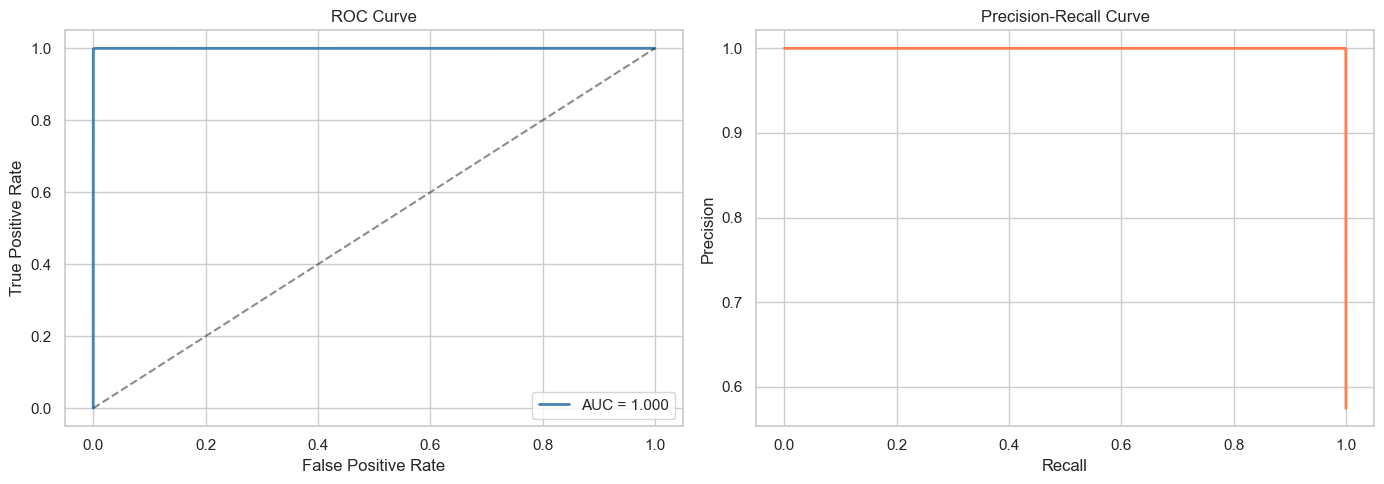

In [14]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color="steelblue", linewidth=2,
             label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color="coral", linewidth=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.savefig("../outputs/figures/06_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. SHAP Analysis — What Determines Winners vs Losers?

In [15]:
print("Computing SHAP values...")
shap_sample = X_test.sample(min(5000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(shap_sample)

# For binary classification, shap_values may be a list [class_0, class_1]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # Class 1 = "winner"
else:
    shap_vals = shap_values

Computing SHAP values...


/Users/sashwatdesai/Desktop/College/Masters/Northeastern University/SEMESTER WORK/Semester 4/Machine Learning 2 (MATH 7339)/Project/cook-county-tax-shift/.venv/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


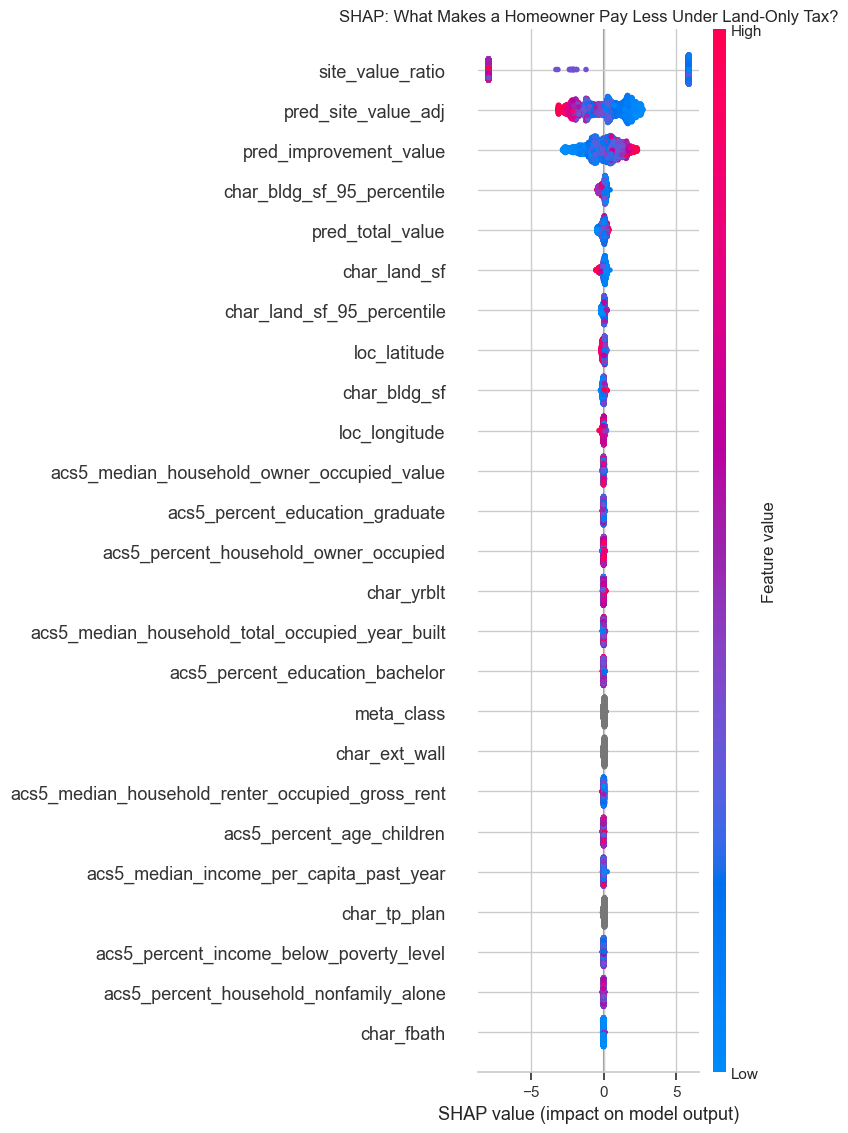

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_vals, shap_sample, max_display=25, show=False)
plt.title("SHAP: What Makes a Homeowner Pay Less Under Land-Only Tax?")
plt.tight_layout()
plt.savefig("../outputs/figures/06_shap_winner_loser.png", dpi=150, bbox_inches="tight")
plt.show()

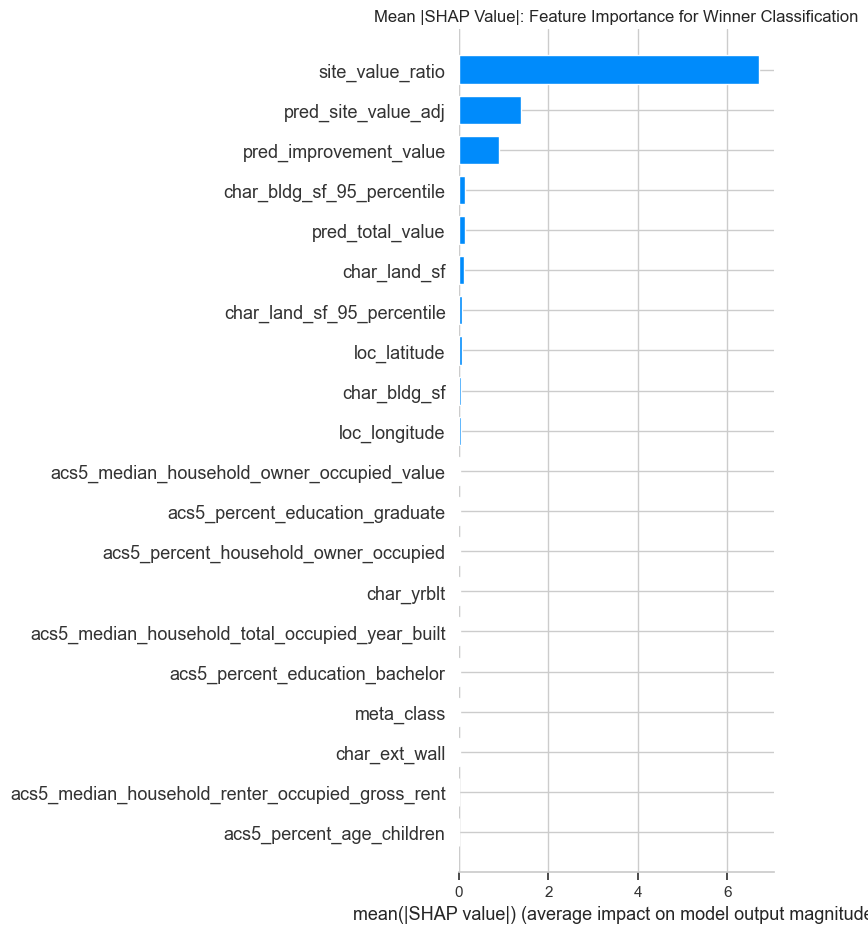

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_vals, shap_sample, plot_type="bar", max_display=20, show=False)
plt.title("Mean |SHAP Value|: Feature Importance for Winner Classification")
plt.tight_layout()
plt.savefig("../outputs/figures/06_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Profile Winners vs Losers

In [18]:
winners = homeowners[homeowners["winner_B"]]
losers = homeowners[~homeowners["winner_B"]]

profile_cols = ["pred_total_value", "pred_site_value_adj",
                "pred_improvement_value", "site_value_ratio",
                "char_land_sf", "char_bldg_sf", "char_yrblt",
                "char_beds", "char_fbath", "col6_current_tax"]
profile_cols = [c for c in profile_cols if c in homeowners.columns]

comparison = pd.DataFrame({
    "Winners (Pay Less)": winners[profile_cols].median(),
    "Losers (Pay More)": losers[profile_cols].median(),
})
comparison["Difference"] = comparison["Winners (Pay Less)"] - comparison["Losers (Pay More)"]
comparison["% Diff"] = 100 * comparison["Difference"] / comparison["Losers (Pay More)"]

print("=== Winner vs Loser Profile (Medians) ===\n")
print(comparison.to_string())

=== Winner vs Loser Profile (Medians) ===

                        Winners (Pay Less)  Losers (Pay More)    Difference     % Diff
pred_total_value             269745.185401      323045.117138 -53299.931738 -16.499222
pred_site_value_adj           47156.758355      101957.142461 -54800.384106 -53.748450
pred_improvement_value       223944.815150      210189.795941  13755.019210   6.544095
site_value_ratio                  0.178659           0.311538     -0.132880 -42.652706
char_land_sf                   5165.000000        5676.000000   -511.000000  -9.002819
char_bldg_sf                   1300.000000        1272.000000     28.000000   2.201258
char_yrblt                     1954.000000        1950.000000      4.000000   0.205128
char_beds                         3.000000           3.000000      0.000000   0.000000
char_fbath                        1.000000           1.000000      0.000000   0.000000
col6_current_tax               6792.979517        8135.229033  -1342.249516 -16.499222


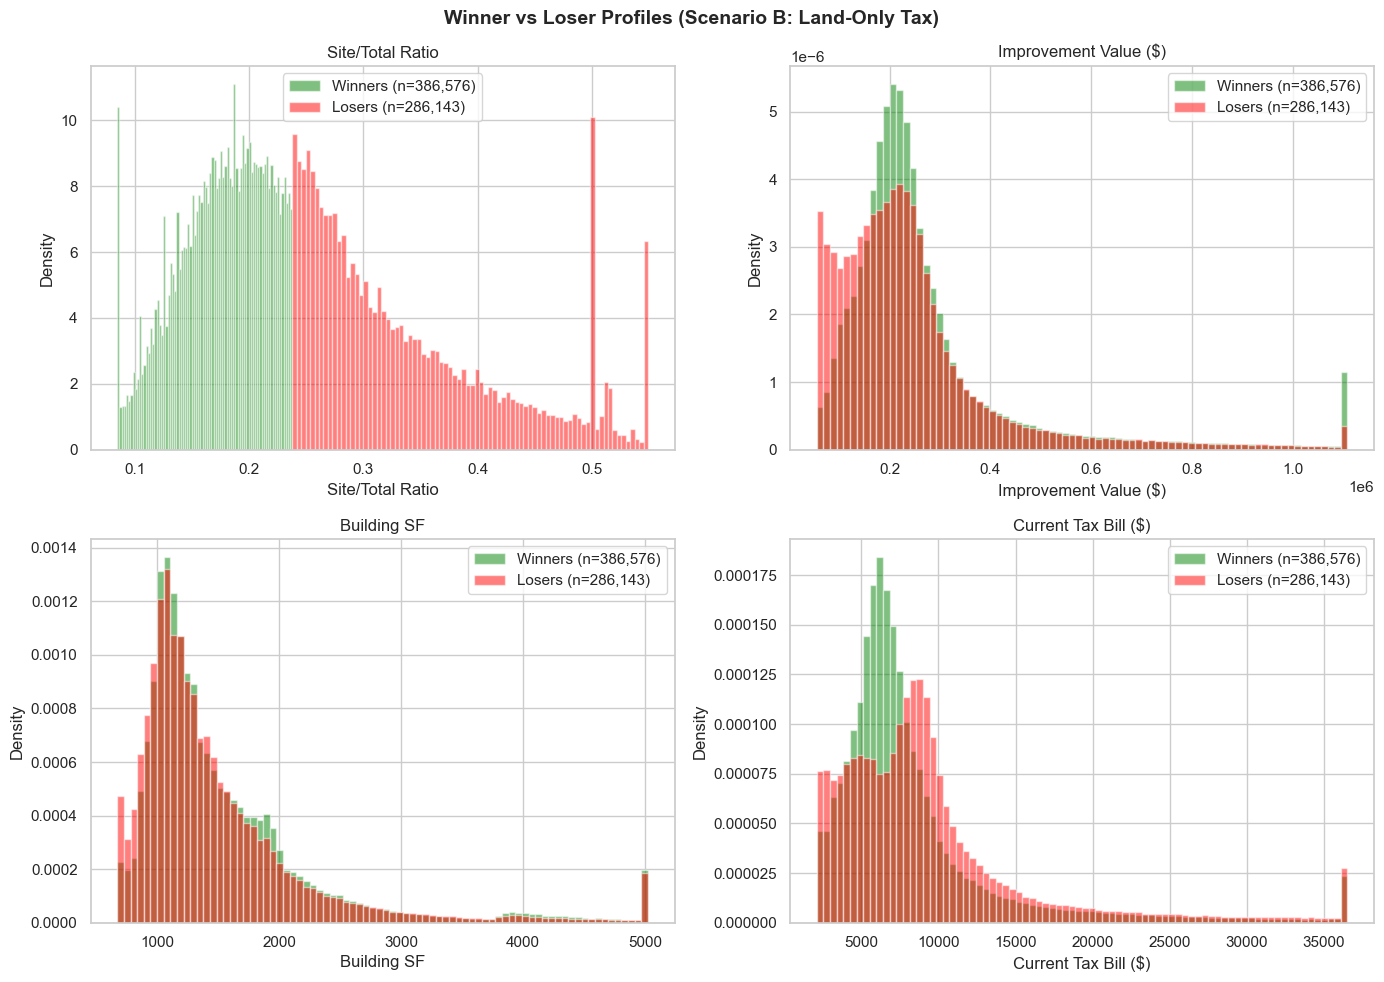

In [19]:
# Visualization: key differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_features = [
    ("site_value_ratio", "Site/Total Ratio", "steelblue"),
    ("pred_improvement_value", "Improvement Value ($)", "coral"),
    ("char_bldg_sf", "Building SF", "green"),
    ("col6_current_tax", "Current Tax Bill ($)", "purple"),
]

for ax, (feat, label, color) in zip(axes.flat, plot_features):
    if feat in homeowners.columns:
        w_data = winners[feat].dropna()
        l_data = losers[feat].dropna()

        q01 = homeowners[feat].quantile(0.01)
        q99 = homeowners[feat].quantile(0.99)

        ax.hist(w_data.clip(q01, q99), bins=80, alpha=0.5,
                label=f"Winners (n={len(w_data):,})", color="green", density=True)
        ax.hist(l_data.clip(q01, q99), bins=80, alpha=0.5,
                label=f"Losers (n={len(l_data):,})", color="red", density=True)
        ax.set_title(label)
        ax.set_xlabel(label)
        ax.set_ylabel("Density")
        ax.legend()

plt.suptitle("Winner vs Loser Profiles (Scenario B: Land-Only Tax)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/06_winner_loser_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Save Results

In [20]:
# Save classifier
clf.save_model("../outputs/models/winner_classifier.txt")

# Save classification metrics
metrics = {
    "roc_auc": float(roc_auc_score(y_test, y_prob)),
    "n_homeowners": len(homeowners),
    "pct_winners": float(100 * homeowners["winner_B"].mean()),
    "winner_median_savings": float(winners["diff_B"].median()),
    "loser_median_increase": float(losers["diff_B"].median()),
}
with open("../outputs/reports/classification_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved: ../outputs/models/winner_classifier.txt")
print("Saved: ../outputs/reports/classification_metrics.json")

Saved: ../outputs/models/winner_classifier.txt
Saved: ../outputs/reports/classification_metrics.json
